In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from scipy.stats import norm
from scipy.stats import mannwhitneyu

from copy import deepcopy
import random


from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(0)



blue = '#0073B7'
yellow = '#FFD23F'
gray = '#7A7A7A'
purple = '#B05AA3'
green = '#00A651'
orange = '#F7941D'


blue_yellow = LinearSegmentedColormap.from_list(
    "blue_yellow", ["#0073B7", "#FFD23F"]
)


gray = '#C0C0C0'
purple = '#B05AA3'

gray_purple = LinearSegmentedColormap.from_list(
    "gray_purple",
    [gray , purple]
)

blue = '#00AEEF'
red = '#F15A2A'

In [2]:
from src.model_engrams import SSCNetwork
from src.utils.general import make_input, LatentSpace, get_ordered_indices, get_sample_from_num_swaps, get_cos_sim_torch
from network_parameters import network_parameters
from src.utils.plotting import compare_distributions_12

In [3]:
#make network randomly project sensory input to obtain a wide distribution of selectivity in MTL-sensory
recording_parameters = {}
recording_parameters["regions"] = ["sen", "mtl_semantic", "mtl_sensory", "ctx", "mtl"]
recording_parameters["rate_activity"] = 1
recording_parameters["connections"] = []
recording_parameters["rate_connectivity"] = np.inf

num_episodes = 5
input_params = {}
input_params["num_days"] = 1
input_params["day_length"] = 5 * num_episodes
input_params["mean_duration"] = 5
input_params["fixed_duration"] = True
input_params["num_swaps"] = 2

latent_specs = {}
latent_specs["num"] = 2
latent_specs["total_sizes"] = [50, 50]
latent_specs["act_sizes"] = [10, 10]
latent_specs["dims"] = [5, 5]
latent_specs["prob_list"] = [0.5/5 if i==j else 0.5/20 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)

In [4]:
def test_network(net, input_params, sleep=False, print_rate=1):
  input, input_episodes, input_latents = make_input(**input_params)
  with torch.no_grad():
    for day in range(input_params["num_days"]):
      if day%print_rate == 0:
        print(day)
      net(input[day], debug=False)
      if sleep:
        net.sleep()
  return input, input_episodes, input_latents, net

In [5]:

def episode_recall(net, ep, num_swaps):
    num_iterations = 10
    mtl_sensory_corrupted =  get_sample_from_num_swaps(ep[:net.mtl_sensory_size], num_swaps)
    mtl_0 = torch.zeros((net.mtl_size))
    mtl_0[:net.mtl_sensory_size] = mtl_sensory_corrupted
    mtl = mtl_0.clone()
    for iteration in range(num_iterations):
      mtl_hat = F.linear(net.mtl_mtl, mtl)
      mtl, _ = net.activation(mtl_hat, 'mtl')

    recall_sensory = get_cos_sim_torch(mtl[:net.mtl_sensory_size], ep[:net.mtl_sensory_size])
    recall_semantic = get_cos_sim_torch(mtl[net.mtl_sensory_size:], ep[net.mtl_sensory_size:])
    recall = get_cos_sim_torch(mtl, ep)
    return mtl_0, mtl, recall_sensory, recall_semantic, recall




def get_recalls(network):
    num_trials = 10
    recalls = []
    recalls_semantic = []
    recalls_sensory = []
    for trial in range(num_trials):
        network.init_recordings(recording_parameters)
        network.frozen = False
        network.activity_recordings_rate = 1
        network.connectivity_recordings_rate = np.inf

        input, input_episodes, input_latents, network = test_network(
            network, input_params, sleep=False, print_rate=50
        )

        for episode in torch.stack(network.activity_recordings["mtl"], axis=0):
            mtl_0, mtl, recall_sensory, recall_semantic, recall = episode_recall(network, episode, num_swaps=5)
            recalls.append(recall)
            recalls_semantic.append(recall_semantic)
            recalls_sensory.append(recall_sensory)

    return recalls, recalls_sensory, recalls_semantic


def get_replays(network):

    def get_max_overlap(replayed, prototpyes):
        cos_sims = [get_cos_sim_torch(replayed, prototype) for prototype in prototpyes]
        max_sim = torch.max(torch.stack(cos_sims, dim=0))
        return max_sim.item()

    num_trials = 100
    num_replays = 5
    num_iterations = 10
    replays = []
    for trial in range(num_trials):
        network.init_recordings(recording_parameters)
        network.frozen = False
        network.activity_recordings_rate = 1
        network.connectivity_recordings_rate = np.inf

        input, input_episodes, input_latents, network = test_network(
            network, input_params, sleep=False, print_rate=50
        )


        for replay in range(num_replays):
            mtl = torch.randn(network.mtl_size)
            for iteration in range(num_iterations):
                mtl_hat = F.linear(network.mtl_mtl, mtl)
                mtl, _ = network.activation(mtl_hat, 'mtl')
            replays.append(get_max_overlap(mtl,torch.stack(network.activity_recordings["mtl"], axis=0)))

    return replays

In [6]:
network_intact = torch.load("checkpoints/network_3_B.pt", weights_only=False)

KeyboardInterrupt: 

In [8]:
recalls_intact = get_recalls(network_intact)
replays_intact = get_replays(network_intact)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [9]:
network_scrambled = deepcopy(network_intact)

# Generate independent permutations for each row
perms = torch.argsort(torch.rand_like(network_scrambled.mtl_semantic_ctx), dim=1)
# Apply the permutations
network_scrambled.mtl_semantic_ctx = torch.gather(network_scrambled.mtl_semantic_ctx, dim=1, index=perms)
# Freeze ctx to mtl semantic connections
network_scrambled.mtl_semantic_ctx_lmbda = 0
network_scrambled.mtl_semantic_b[:] = -1

In [10]:

recalls_scrambled = get_recalls(network_scrambled)
replays_scrambled = get_replays(network_scrambled)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


/Users/albertalbesagonzalez/Desktop/sensory-semantic-episodes-rebuttal/src/utils/plotting.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


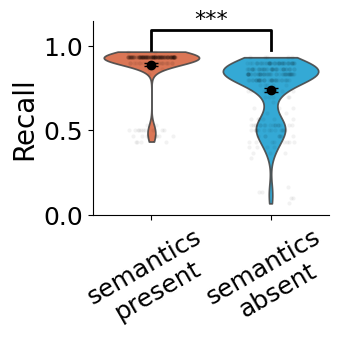

In [18]:
dist1 = ('semantics\npresent', recalls_intact[0])
dist2 = ('semantics\nabsent', recalls_scrambled[0])

palette = {
    "semantics\npresent": red, 
    "semantics\nabsent": blue
}

compare_distributions_12(dist1, dist2, palette)
plt.ylabel("Recall", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 0.5, 1], fontsize=18)
plt.tight_layout()
sns.despine()


# Blocked vs interleaved

In [38]:
seed_everything(0)


recording_parameters = {}
recording_parameters["regions"] = ["mtl_sensory"]
recording_parameters["rate_activity"] = 1
recording_parameters["connections"] = []
recording_parameters["rate_connectivity"] = np.inf


input_params = {}
input_params["num_days"] = 1
input_params["day_length"] = 80
input_params["mean_duration"] = 5
input_params["fixed_duration"] = True
input_params["num_swaps"] = 4

latent_specs = {}
latent_specs["num"] = 2
latent_specs["total_sizes"] = [50, 50]
latent_specs["act_sizes"] = [10, 10]
latent_specs["dims"] = [5, 5]

In [39]:
input_params["num_days"] = 10
input_params["day_length"] = 50
input_params["mean_duration"] = 1

latent_specs["prob_list"] = [0.2 if i==0 else 0 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)

network = SSCNetwork(network_parameters, recording_parameters)
input, input_episodes, input_latents, network = test_network(network, input_params, sleep =True, print_rate=50)


prototype_A = torch.zeros(latent_specs["dims"][0], network.mtl_sensory_size)
replayed_A =  torch.zeros(latent_specs["dims"][0], input_params["num_days"]*network.sleep_duration_A, network.mtl_sensory_size)
prototype_B = torch.zeros(latent_specs["dims"][1], network.mtl_sensory_size)
replayed_B =  torch.zeros(latent_specs["dims"][0],  input_params["num_days"]*network.sleep_duration_A, network.mtl_sensory_size)

replayed_A[0] = torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.sleep_indices_A]
prototype_A[0] = network.activation(torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.awake_indices].mean(axis=0), "mtl_sensory", sleep=True)[0]
network.awake_indices = []
network.sleep_indices_A = []


0


In [40]:
for k in range(1, 5):
    latent_specs["prob_list"] = [0.2 if i==k else 0 for i in range(5) for j in range(5)]
    input_params["latent_space"] = LatentSpace(**latent_specs)
    input, input_episodes, input_latents, network = test_network(network, input_params, sleep=True, print_rate=50)
    replayed_A[k] = torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.sleep_indices_A]
    prototype_A[k] = network.activation(torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.awake_indices].mean(axis=0), "mtl_sensory", sleep=True)[0]
    network.awake_indices = []
    network.sleep_indices_A = []


for k in range(5):
    latent_specs["prob_list"] = [0.2 if j==k else 0 for i in range(5) for j in range(5)]
    input_params["latent_space"] = LatentSpace(**latent_specs)
    input, input_episodes, input_latents, network = test_network(network, input_params, sleep=True, print_rate=50)
    replayed_B[k] = torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.sleep_indices_A]
    prototype_B[k] = network.activation(torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.awake_indices].mean(axis=0), "mtl_sensory", sleep=True)[0]
    network.awake_indices = []
    network.sleep_indices_A = []


0
0
0
0
0
0
0
0
0


In [41]:
def get_max_overlap(replayed, prototpyes):
    cos_sims = [get_cos_sim_torch(replayed, prototype) for prototype in prototpyes]
    max_sim = torch.max(torch.stack(cos_sims, dim=0))
    return max_sim.item()

In [42]:

prototypes = torch.concat([prototype_A, prototype_B], axis=0)
max_overlaps_blocked = []
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[0]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[1]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[2]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[3]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[4]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[0]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[1]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[2]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[3]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[4]])

In [43]:
input_params["num_days"] = 100
input_params["day_length"] = 50
input_params["mean_duration"] = 1
latent_specs["prob_list"] = [1/25 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)
network = SSCNetwork(network_parameters, recording_parameters)
input, input_episodes, input_latents, network = test_network(network, input_params, sleep=True, print_rate=50)

0
50


In [44]:
replayed_interleaved = torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.sleep_indices_A]
max_overlaps_interleaved = [get_max_overlap(replayed, prototypes) for replayed in replayed_interleaved]

/Users/albertalbesagonzalez/Desktop/sensory-semantic-episodes-rebuttal/src/utils/plotting.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


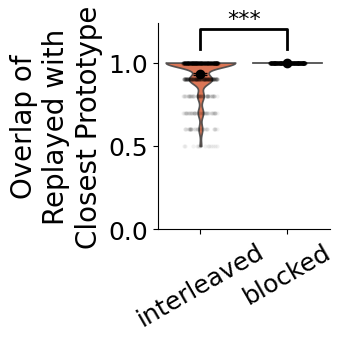

In [45]:
dist1 = ('interleaved', max_overlaps_interleaved)
dist2 = ('blocked', max_overlaps_blocked)

palette = {
    "interleaved": red,   # light blue
    "blocked": blue
}

compare_distributions_12(dist1, dist2, palette)
plt.ylabel("Overlap of\nReplayed with\nClosest Prototype", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 0.5, 1], fontsize=18)
plt.tight_layout()
sns.despine()


## Anterograde vs Retrograde Semantic Amnesia After MTL Lesion


In [39]:
import pandas as pd
from src.utils.general import get_selectivity, get_ordered_indices


def build_prob_list_fixed_A1(dims):
    num_a, num_b = dims
    return [1 / num_b if i == 0 else 0 for i in range(num_a) for j in range(num_b)]


def build_prob_list_fixed_B1(dims):
    num_a, num_b = dims
    return [1 / num_a if j == 0 else 0 for i in range(num_a) for j in range(num_b)]


def build_prob_list_fixed_A_index(dims, a_index):
    num_a, num_b = dims
    return [1 / num_b if i == int(a_index) else 0 for i in range(num_a) for j in range(num_b)]


def build_prob_list_fixed_B_index(dims, b_index):
    num_a, num_b = dims
    return [1 / num_a if j == int(b_index) else 0 for i in range(num_a) for j in range(num_b)]


def build_prob_list_A1B1(dims):
    num_a, num_b = dims
    return [1 if (i == 0 and j == 0) else 0 for i in range(num_a) for j in range(num_b)]


def build_prob_list_uniform(dims):
    num_a, num_b = dims
    return [1 / (num_a * num_b) for _ in range(num_a * num_b)]


def _permute_input_channel(input_tensor, channel_start, channel_end, seed):
    permuted_input = input_tensor.clone()
    generator = torch.Generator()
    generator.manual_seed(int(seed))
    source = permuted_input[:, :, channel_start:channel_end].clone()
    perms = torch.argsort(torch.rand(source.shape, generator=generator), dim=2)
    permuted_input[:, :, channel_start:channel_end] = torch.gather(source, 2, perms)
    return permuted_input


def run_wake_days(
    net,
    latent_specs_base,
    prob_list,
    num_days,
    day_length,
    mean_duration,
    num_swaps,
    permute_channel_slice=None,
    permute_seed=0,
    sleep_after_day=False,
):
    if int(num_days) <= 0:
        return None, None, None

    latent_specs = dict(latent_specs_base)
    latent_specs["prob_list"] = prob_list

    stage_input_params = {
        "num_days": int(num_days),
        "day_length": int(day_length),
        "mean_duration": int(mean_duration),
        "fixed_duration": True,
        "num_swaps": int(num_swaps),
        "latent_space": LatentSpace(**latent_specs),
    }

    input_tensor, input_episodes, input_latents = make_input(**stage_input_params)

    if permute_channel_slice is not None:
        channel_start, channel_end = permute_channel_slice
        input_tensor = _permute_input_channel(
            input_tensor,
            channel_start=int(channel_start),
            channel_end=int(channel_end),
            seed=int(permute_seed),
        )

    with torch.no_grad():
        for day in range(int(num_days)):
            net(input_tensor[day], debug=False)
            if sleep_after_day:
                net.sleep()

    return input_tensor, input_episodes, input_latents


def lesion_mtl_recurrent(net, disable_sleep_replay=False):
    # Lesion MTL recurrent dynamics while keeping cortical pathways intact.
    with torch.no_grad():
        net.mtl_mtl.zero_()
        net.mtl_sensory_mtl_sensory.zero_()
        net.mtl_semantic_mtl_semantic.zero_()

    # Important for anterograde lesion: after recurrent lesion, MTL replay should not
    # continue as random attractors during phase-A sleep.
    if disable_sleep_replay:
        net.sleep_duration_A = 0

    return net


def summarize_branch_changes(net_base, net_branch):
    with torch.no_grad():
        mtl_sensory_size = int(net_base.mtl_sensory_size)
        delta_ctx_mtl = (net_branch.ctx_mtl - net_base.ctx_mtl).abs()

        return {
            "delta_ctx_mtl_total": float(delta_ctx_mtl.sum().item()),
            "delta_ctx_mtl_from_mtl_sensory": float(delta_ctx_mtl[:, :mtl_sensory_size].sum().item()),
            "delta_ctx_mtl_from_mtl_semantic": float(delta_ctx_mtl[:, mtl_sensory_size:].sum().item()),
            "delta_ctx_ctx_total": float((net_branch.ctx_ctx - net_base.ctx_ctx).abs().sum().item()),
            "mtl_mtl_l1": float(net_branch.mtl_mtl.abs().sum().item()),
        }


def get_ctx_selective_indices_A1_B1(
    net,
    latent_specs_base,
    recording_parameters,
    day_length=500,
    mean_duration=5,
    num_swaps=4,
    top_k=None,
    seed=0,
):
    seed_everything(seed)

    net_eval = deepcopy(net)
    net_eval.frozen = True
    net_eval.init_recordings(recording_parameters)

    latent_specs = dict(latent_specs_base)
    latent_specs["prob_list"] = build_prob_list_uniform(latent_specs_base["dims"])

    test_input_params = {
        "num_days": 1,
        "day_length": int(day_length),
        "mean_duration": int(mean_duration),
        "fixed_duration": True,
        "num_swaps": int(num_swaps),
        "latent_space": LatentSpace(**latent_specs),
    }

    input_tensor, _, input_latents = make_input(**test_input_params)

    with torch.no_grad():
        net_eval(input_tensor[0], debug=False)

    ctx_recordings = torch.stack(net_eval.activity_recordings["ctx"], dim=0)[net_eval.awake_indices]

    latent_A_one_hot = F.one_hot(input_latents[:, :, 0].long(), num_classes=latent_specs_base["dims"][0])
    latent_B_one_hot = F.one_hot(input_latents[:, :, 1].long(), num_classes=latent_specs_base["dims"][1])
    latent_AB_one_hot = torch.cat((latent_A_one_hot, latent_B_one_hot), dim=2).float()

    selectivity_ctx = get_selectivity(ctx_recordings, latent_AB_one_hot)

    if top_k is None:
        # Match CTX sleep sparsity K from the first CTX subregion.
        first_subregion_index = 0
        top_k = int(
            int(net_eval.ctx_size_subregions[first_subregion_index])
            * float(net_eval.ctx_sparsity_sleep[first_subregion_index])
        )
        top_k = max(top_k, 1)

    if int(top_k) != 10:
        raise ValueError(
            f"Expected CTX first-subregion sleep K to be 10, got {int(top_k)}. "
            "Check ctx_sparsity_sleep[0] and ctx_size_subregions[0]."
        )

    first_subregion = net_eval.ctx_subregions[0]
    first_subregion_selectivity = selectivity_ctx[first_subregion]

    k = min(int(top_k), int(first_subregion_selectivity.shape[0]))
    a1_index = 0
    b1_index = latent_specs_base["dims"][0]

    a1_local = torch.topk(first_subregion_selectivity[:, a1_index], k=k).indices
    b1_local = torch.topk(first_subregion_selectivity[:, b1_index], k=k).indices

    # Map local top-k (within first CTX subregion) back to global CTX neuron indices.
    a1_ctx_indices = first_subregion[a1_local]
    b1_ctx_indices = first_subregion[b1_local]

    return a1_ctx_indices, b1_ctx_indices, selectivity_ctx


def attach_selectivity_metadata(
    net,
    latent_specs_base,
    recording_parameters,
    day_length=500,
    mean_duration=5,
    num_swaps=4,
    ctx_assembly_size=10,
    mtl_sensory_assembly_size=10,
    mtl_semantic_assembly_size=5,
    seed=0,
):
    seed_everything(seed)

    net_eval = deepcopy(net)
    net_eval.frozen = True
    net_eval.init_recordings(recording_parameters)

    latent_specs = dict(latent_specs_base)
    latent_specs["prob_list"] = build_prob_list_uniform(latent_specs_base["dims"])

    test_input_params = {
        "num_days": 1,
        "day_length": int(day_length),
        "mean_duration": int(mean_duration),
        "fixed_duration": True,
        "num_swaps": int(num_swaps),
        "latent_space": LatentSpace(**latent_specs),
    }

    input_tensor, _, input_latents = make_input(**test_input_params)

    with torch.no_grad():
        net_eval(input_tensor[0], debug=False)

    ctx_recordings = torch.stack(net_eval.activity_recordings["ctx"], dim=0)[net_eval.awake_indices]
    mtl_sensory_recordings = torch.stack(net_eval.activity_recordings["mtl_sensory"], dim=0)[net_eval.awake_indices]
    mtl_semantic_recordings = torch.stack(net_eval.activity_recordings["mtl_semantic"], dim=0)[net_eval.awake_indices]

    latent_A_one_hot = F.one_hot(input_latents[:, :, 0].long(), num_classes=latent_specs_base["dims"][0])
    latent_B_one_hot = F.one_hot(input_latents[:, :, 1].long(), num_classes=latent_specs_base["dims"][1])
    latent_AB_one_hot = torch.cat((latent_A_one_hot, latent_B_one_hot), dim=2).float()

    net.selectivity_ctx, net.ordered_indices_ctx = get_ordered_indices(
        ctx_recordings,
        latent_AB_one_hot,
        assembly_size=int(ctx_assembly_size),
        seed=seed,
    )
    net.selectivity_mtl_sensory, net.ordered_indices_mtl_sensory = get_ordered_indices(
        mtl_sensory_recordings,
        latent_AB_one_hot,
        assembly_size=int(mtl_sensory_assembly_size),
        seed=seed,
    )
    net.selectivity_mtl_semantic, net.ordered_indices_mtl_semantic = get_ordered_indices(
        mtl_semantic_recordings,
        latent_AB_one_hot,
        assembly_size=int(mtl_semantic_assembly_size),
        seed=seed,
    )

    return net


def memory_test_A1_to_CTX_B1(
    net,
    latent_specs_base,
    b1_ctx_indices,
    a1_ctx_indices=None,
    ctx_pattern_complete_iterations=10,
):
    latent_specs = dict(latent_specs_base)
    latent_specs["prob_list"] = build_prob_list_uniform(latent_specs_base["dims"])
    latent_space = LatentSpace(**latent_specs)

    net_eval = deepcopy(net)
    net_eval.frozen = True

    a_size = latent_specs_base["total_sizes"][0]

    with torch.no_grad():
        # Present A1 in MTL-sensory coordinates (through SEN->MTL-sensory map).
        sen_cue = torch.zeros(net_eval.sen_size)
        sen_cue[:a_size] = latent_space.latent_patterns[0][0]

        mtl_sensory_hat = F.linear(sen_cue, net_eval.mtl_sensory_sen)
        mtl_sensory_cue, _ = net_eval.activation(mtl_sensory_hat, "mtl_sensory")

        mtl_state = torch.zeros(net_eval.mtl_size)
        mtl_state[:net_eval.mtl_sensory_size] = mtl_sensory_cue

        # Project to CTX and pattern-complete in CTX.
        ctx_hat = F.linear(mtl_state, net_eval.ctx_mtl) + net_eval.ctx_b * net_eval.ctx_IM
        ctx_state, _ = net_eval.activation(ctx_hat, "ctx")
        ctx_pc = net_eval.pattern_complete(
            "ctx",
            h_0=ctx_state,
            num_iterations=int(ctx_pattern_complete_iterations),
        )

    b1_ctx_mean = ctx_pc[b1_ctx_indices].float().mean().item() if len(b1_ctx_indices) > 0 else float("nan")

    if a1_ctx_indices is not None and len(a1_ctx_indices) > 0:
        a1_ctx_mean = ctx_pc[a1_ctx_indices].float().mean().item()
    else:
        a1_ctx_mean = float("nan")

    other_mask = torch.ones(ctx_pc.shape[0], dtype=torch.bool)
    other_mask[b1_ctx_indices] = False
    other_mean = ctx_pc[other_mask].float().mean().item() if torch.any(other_mask) else float("nan")

    return {
        "b1_ctx_mean": b1_ctx_mean,
        "a1_ctx_mean": a1_ctx_mean,
        "b1_minus_other": b1_ctx_mean - other_mean,
    }


def get_amnesia_training_schedule(config, latent_specs_amnesia):
    num_a = int(latent_specs_amnesia["dims"][0])
    num_b = int(latent_specs_amnesia["dims"][1])
    total_num_concepts = num_a + num_b

    if "concept_train_days" in config:
        concept_train_days = [int(x) for x in config["concept_train_days"]]
        if len(concept_train_days) != total_num_concepts:
            raise ValueError(
                f"concept_train_days must have length {total_num_concepts}, got {len(concept_train_days)}."
            )
    else:
        fallback_days = int(config["pretrain_days_each"])
        concept_train_days = [fallback_days for _ in range(total_num_concepts)]

    association_train_days = int(config.get("association_train_days", config.get("association_days", 0)))

    return {
        "A_days": concept_train_days[:num_a],
        "B_days": concept_train_days[num_a:],
        "association_days": association_train_days,
    }


def maybe_store_training_snapshot(training_snapshots, stage_name, net, enabled):
    if not enabled:
        return

    net_snapshot = deepcopy(net)
    net_snapshot.training_stage = stage_name
    net_snapshot.training_day = int(net.day)
    training_snapshots.append(
        {
            "stage": stage_name,
            "day": int(net.day),
            "network": net_snapshot,
        }
    )


def run_amnesia_single_seed(seed, config):
    seed_everything(seed)

    recording_parameters_amnesia = {
        "regions": ["sen", "mtl_sensory", "mtl_semantic", "mtl", "ctx", "ctx_hat"],
        "rate_activity": 1,
        "connections": [],
        "rate_connectivity": np.inf,
    }

    # Stage 1 (pretraining): episodic replay only
    net_params = deepcopy(network_parameters)

    net_params["ctx_num_subregions"] = 2
    net_params["ctx_size_subregions"] =  torch.tensor([150, 150])
    net_params["ctx_sparsity"] = torch.tensor([20/150, 10/150])
    net_params["ctx_sparsity_sleep"] = torch.tensor([10/150, 10/150])
    net_params["ctx_subregions_b"] = [0.6, 0.6]


    net_params["duration_phase_A"] = int(config["episodic_only_duration_phase_A"])
    net_params["duration_phase_B"] = int(config["episodic_only_duration_phase_B"])
    net_params["max_semantic_charge_replay"] = 1

    net = SSCNetwork(net_params, recording_parameters_amnesia)

    latent_specs_amnesia = {
        "num": 2,
        "total_sizes": [50, 50],
        "act_sizes": [10, 10],
        "dims": [5, 5],
        "random_neurons": False,
    }

    training_schedule = get_amnesia_training_schedule(config, latent_specs_amnesia)
    training_snapshots = []
    store_training_snapshots = bool(config.get("store_training_snapshots", False))

    a_size = int(latent_specs_amnesia["total_sizes"][0])
    b_size = int(latent_specs_amnesia["total_sizes"][1])

    pretraining_block_repeats = int(config.get("pretraining_block_repeats", 1))

    # 1) Pre-train all A/B concept blocks with random opposite-side input.
    for repeat_index in range(pretraining_block_repeats):
        for a_index in range(latent_specs_amnesia["dims"][0]):
            for concept_day in range(int(training_schedule["A_days"][a_index])):
                run_wake_days(
                    net,
                    latent_specs_amnesia,
                    build_prob_list_fixed_A_index(latent_specs_amnesia["dims"], a_index),
                    num_days=1,
                    day_length=config["day_length"],
                    mean_duration=config["mean_duration"],
                    num_swaps=config["num_swaps"],
                    permute_channel_slice=(a_size, a_size + b_size),
                    permute_seed=seed + 10000 * repeat_index + 100 * (a_index + 1) + concept_day,
                    sleep_after_day=True,
                )
                maybe_store_training_snapshot(
                    training_snapshots,
                    stage_name=f"repeat_{repeat_index + 1}_A_{a_index + 1}_day_{concept_day + 1}",
                    net=net,
                    enabled=store_training_snapshots,
                )

        for b_index in range(latent_specs_amnesia["dims"][1]):
            for concept_day in range(int(training_schedule["B_days"][b_index])):
                run_wake_days(
                    net,
                    latent_specs_amnesia,
                    build_prob_list_fixed_B_index(latent_specs_amnesia["dims"], b_index),
                    num_days=1,
                    day_length=config["day_length"],
                    mean_duration=config["mean_duration"],
                    num_swaps=config["num_swaps"],
                    permute_channel_slice=(0, a_size),
                    permute_seed=seed + 100000 + 10000 * repeat_index + 100 * (b_index + 1) + concept_day,
                    sleep_after_day=True,
                )
                maybe_store_training_snapshot(
                    training_snapshots,
                    stage_name=f"repeat_{repeat_index + 1}_B_{b_index + 1}_day_{concept_day + 1}",
                    net=net,
                    enabled=store_training_snapshots,
                )

    # Stage 2: enable full replay dynamics.
    net.duration_phase_A = int(config["full_duration_phase_A"])
    net.duration_phase_B = int(config["full_duration_phase_B"])
    net.max_semantic_charge_replay = int(config["full_max_semantic_charge_replay"])

    association_day_length = config.get("association_day_length")
    if association_day_length is None:
        association_day_length = config["day_length"]

    # 3) Association day with A1 + B1 together (no sleep yet).
    if training_schedule["association_days"] > 0:
        run_wake_days(
            net,
            latent_specs_amnesia,
            build_prob_list_A1B1(latent_specs_amnesia["dims"]),
            num_days=training_schedule["association_days"],
            day_length=association_day_length,
            mean_duration=config["mean_duration"],
            num_swaps=config["num_swaps"],
            sleep_after_day=False,
        )
    maybe_store_training_snapshot(
        training_snapshots,
        stage_name="association",
        net=net,
        enabled=store_training_snapshots,
    )

    # 4) Frozen test encoding to extract selective CTX indices for A1 and B1.
    a1_ctx_indices, b1_ctx_indices, _ = get_ctx_selective_indices_A1_B1(
        net,
        latent_specs_amnesia,
        recording_parameters_amnesia,
        day_length=config["selectivity_test_day_length"],
        mean_duration=config["mean_duration"],
        num_swaps=config["num_swaps"],
        top_k=config["selectivity_top_k"],
        seed=seed + 1000,
    )

    if seed == 0:
        print(f"Computed CTX selective K = {len(a1_ctx_indices)}")

    # 5) Branch by lesion timing around the consolidation sleep.
    net_sham = deepcopy(net)
    net_anterograde = deepcopy(net)
    net_retrograde = deepcopy(net)

    if training_schedule["association_days"] > 0:
        for _ in range(int(config["consolidation_sleep_cycles"])):
            net_sham.sleep()

        lesion_mtl_recurrent(net_anterograde, disable_sleep_replay=True)
        for _ in range(int(config["consolidation_sleep_cycles"])):
            net_anterograde.sleep()

        for _ in range(int(config["consolidation_sleep_cycles"])):
            net_retrograde.sleep()
        lesion_mtl_recurrent(net_retrograde)

    branch_networks = {
        "sham": net_sham,
        "anterograde": net_anterograde,
        "retrograde": net_retrograde,
    }

    for branch_name, branch_net in branch_networks.items():
        branch_net.a1_ctx_indices = a1_ctx_indices.detach().cpu().clone()
        branch_net.b1_ctx_indices = b1_ctx_indices.detach().cpu().clone()
        branch_net = attach_selectivity_metadata(
            branch_net,
            latent_specs_amnesia,
            recording_parameters_amnesia,
            day_length=config["selectivity_test_day_length"],
            mean_duration=config["mean_duration"],
            num_swaps=config["num_swaps"],
            ctx_assembly_size=10,
            mtl_sensory_assembly_size=10,
            mtl_semantic_assembly_size=5,
            seed=seed + 2000,
        )
        branch_networks[branch_name] = branch_net

    scores = {
        "sham": memory_test_A1_to_CTX_B1(
            net_sham,
            latent_specs_amnesia,
            b1_ctx_indices,
            a1_ctx_indices,
            ctx_pattern_complete_iterations=config["ctx_pattern_complete_iterations"],
        ),
        "anterograde": memory_test_A1_to_CTX_B1(
            net_anterograde,
            latent_specs_amnesia,
            b1_ctx_indices,
            a1_ctx_indices,
            ctx_pattern_complete_iterations=config["ctx_pattern_complete_iterations"],
        ),
        "retrograde": memory_test_A1_to_CTX_B1(
            net_retrograde,
            latent_specs_amnesia,
            b1_ctx_indices,
            a1_ctx_indices,
            ctx_pattern_complete_iterations=config["ctx_pattern_complete_iterations"],
        ),
    }

    branch_diagnostics = {
        "sham": summarize_branch_changes(net, net_sham),
        "anterograde": summarize_branch_changes(net, net_anterograde),
        "retrograde": summarize_branch_changes(net, net_retrograde),
    }

    return {
        "seed": seed,
        "scores": scores,
        "networks": branch_networks,
        "training_schedule": training_schedule,
        "training_snapshots": training_snapshots,
        "branch_diagnostics": branch_diagnostics,
        "a1_ctx_indices": a1_ctx_indices.detach().cpu(),
        "b1_ctx_indices": b1_ctx_indices.detach().cpu(),
    }


amnesia_config = {
    "num_seeds": 20,
    "concept_train_days": [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    "association_train_days": 1,
    "pretraining_block_repeats": 2,
    "association_day_length": 35,
    "store_training_snapshots": True,
    "consolidation_sleep_cycles": 1,
    "day_length": 100,
    "mean_duration": 5,
    "num_swaps": 4,
    "selectivity_test_day_length": 500,
    "selectivity_top_k": None,
    "ctx_pattern_complete_iterations": 10,
    # episodic-only pretraining stage
    "episodic_only_duration_phase_A": 10,
    "episodic_only_duration_phase_B": 20,
    # full replay stage
    "full_duration_phase_A": 1,
    "full_duration_phase_B": 1,
    "full_max_semantic_charge_replay": 2,
}


In [40]:
seed_everything(0)

amnesia_seed_results = []
amnesia_selective_indices = {}
amnesia_branch_networks = {}
amnesia_training_snapshots = {}

for seed in range(amnesia_config["num_seeds"]):
    single_result = run_amnesia_single_seed(seed, amnesia_config)

    amnesia_selective_indices[seed] = {
        "A1_ctx_indices": single_result["a1_ctx_indices"],
        "B1_ctx_indices": single_result["b1_ctx_indices"],
    }

    amnesia_branch_networks[seed] = single_result["networks"]
    amnesia_training_snapshots[seed] = single_result["training_snapshots"]

    for condition_name, metric_dict in single_result["scores"].items():
        row = {
            "seed": seed,
            "condition": condition_name,
            **metric_dict,
        }

        if "branch_diagnostics" in single_result and condition_name in single_result["branch_diagnostics"]:
            row.update(single_result["branch_diagnostics"][condition_name])

        amnesia_seed_results.append(row)

amnesia_results_df = pd.DataFrame(amnesia_seed_results)

display(
    amnesia_results_df.groupby("condition")[["b1_ctx_mean", "a1_ctx_mean", "b1_minus_other"]]
    .agg(["mean", "std", "count"])
)

display(
    pd.DataFrame(
        {
            "seed": list(amnesia_selective_indices.keys()),
            "A1_selective_count": [len(amnesia_selective_indices[s]["A1_ctx_indices"]) for s in amnesia_selective_indices],
            "B1_selective_count": [len(amnesia_selective_indices[s]["B1_ctx_indices"]) for s in amnesia_selective_indices],
        }
    ).head()
)


diagnostic_columns = [
    "delta_ctx_mtl_total",
    "delta_ctx_mtl_from_mtl_sensory",
    "delta_ctx_mtl_from_mtl_semantic",
    "delta_ctx_ctx_total",
    "mtl_mtl_l1",
]

available_diagnostic_columns = [c for c in diagnostic_columns if c in amnesia_results_df.columns]
if len(available_diagnostic_columns) > 0:
    display(
        amnesia_results_df.groupby("condition")[available_diagnostic_columns]
        .agg(["mean", "std", "count"])
    )


Computed CTX selective K = 10


b1_ctx_mean                 a1_ctx_mean                  \
                   mean       std count        mean       std count   
condition                                                             
anterograde       0.450  0.510418    20       0.800  0.410391    20   
retrograde        0.770  0.382650    20       0.905  0.245967    20   
sham              0.755  0.407140    20       0.890  0.307622    20   

            b1_minus_other                  
                      mean       std count  
condition                                   
anterograde       0.362069  0.528018    20  
retrograde        0.693103  0.395845    20  
sham              0.677586  0.421180    20

,seed,A1_selective_count,B1_selective_count
0,0,10,10
1,1,10,10
2,2,10,10
3,3,10,10
4,4,10,10


delta_ctx_mtl_total                  \
                           mean       std count   
condition                                         
anterograde            0.000000  0.000000    20   
retrograde            17.006799  4.141830    20   
sham                  17.172136  4.486288    20   

            delta_ctx_mtl_from_mtl_sensory                  \
                                      mean       std count   
condition                                                    
anterograde                       0.000000  0.000000    20   
retrograde                       11.329386  2.757871    20   
sham                             11.440521  2.987620    20   

            delta_ctx_mtl_from_mtl_semantic                  \
                                       mean       std count   
condition                                                     
anterograde                        0.000000  0.000000    20   
retrograde                         5.677413  1.383962    20   
sham                               5.731615  1.498673    20   

            delta_ctx_ctx_total                  mtl_mtl_l1                  
                           mean       std count        mean       std count  
condition                                                                    
anterograde            0.000000  0.000000    20    0.000000  0.000000    20  
retrograde             9.979817  2.092571    20    0.000000  0.000000    20  
sham                  10.067043  2.272365    20  157.500002  0.000005    20

/Users/albertalbesagonzalez/Desktop/sensory-semantic-episodes-rebuttal/src/utils/plotting.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


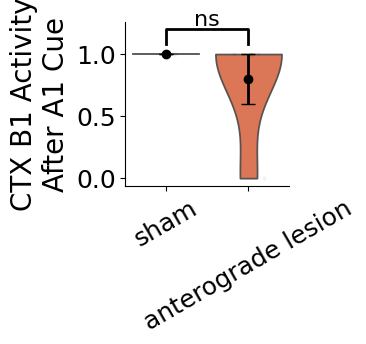

In [38]:
dist1 = (
    "sham",
    amnesia_results_df[amnesia_results_df["condition"] == "sham"]["b1_ctx_mean"].tolist(),
)

dist2 = (
    "anterograde lesion",
    amnesia_results_df[amnesia_results_df["condition"] == "anterograde"]["b1_ctx_mean"].tolist(),
)

palette = {
    "sham": blue,
    "anterograde lesion": red,
}

compare_distributions_12(dist1, dist2, palette)
plt.ylabel("CTX B1 Activity\nAfter A1 Cue", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks(fontsize=18)
plt.tight_layout()
sns.despine()


In [17]:
net_sham = amnesia_branch_networks[0]["sham"]
ind_ctx = net_sham.ordered_indices_ctx

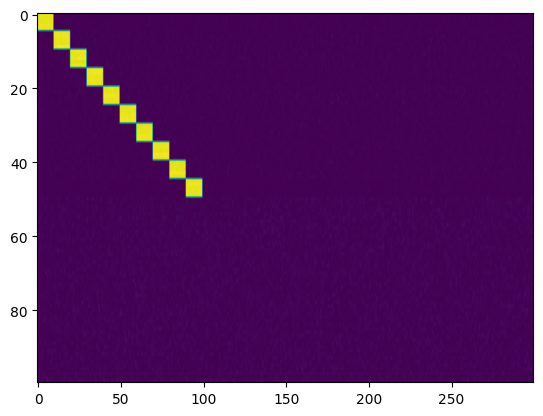

In [18]:
plt.imshow(net_sham.mtl_semantic_ctx[net_sham.ordered_indices_mtl_semantic][:, net_sham.ordered_indices_ctx].abs().cpu(), aspect="auto")

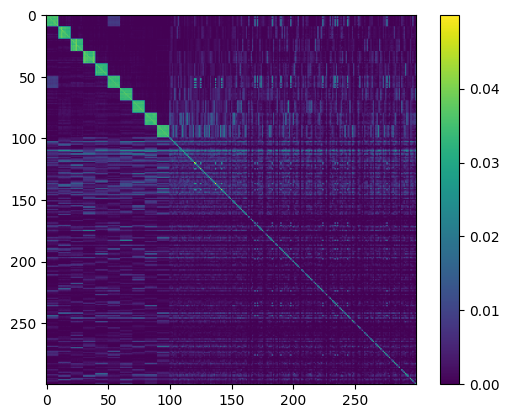

In [19]:
plt.imshow(net_sham.ctx_ctx[ind_ctx][:, ind_ctx])
plt.colorbar()

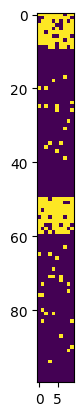

In [20]:
plt.imshow(torch.stack(net_sham.activity_recordings["mtl_sensory"], axis=0)[net_sham.awake_indices].T[:, -10:])

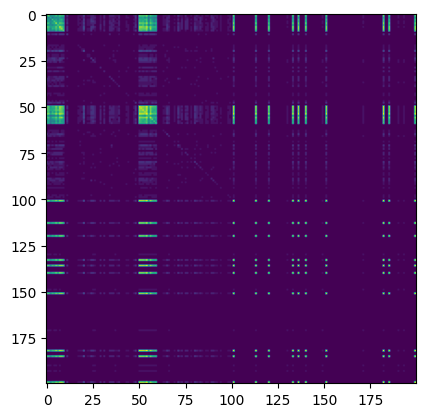

In [23]:
plt.imshow(net_sham.mtl_mtl)

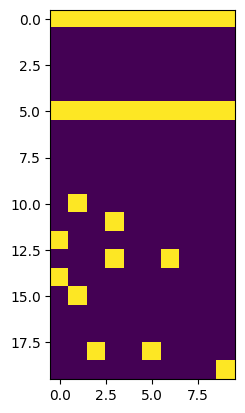

In [22]:
plt.imshow(net_sham.mtl_generate(semantic_charge=2).reshape((-1, 10)))

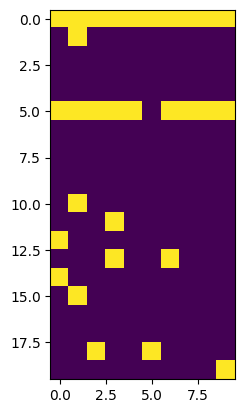

In [140]:
h = torch.randn(net_sham.mtl_size)

for i in range(10):
    h = net_sham.activation(net_sham.mtl_mtl @ h, "mtl")[0]
plt.imshow(h.reshape((-1, 10)))

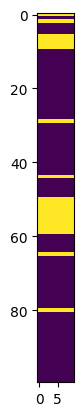

In [133]:
plt.imshow(torch.stack(net_sham.activity_recordings["mtl_sensory"], axis=0)[net_sham.sleep_indices_A].T[:, -10:])

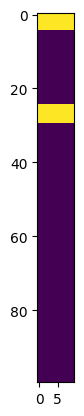

In [103]:
plt.imshow(torch.stack(net_sham.activity_recordings["mtl_semantic"], axis=0)[net_sham.sleep_indices_A][:, net_sham.ordered_indices_mtl_semantic].T[:, -10:])

(array([ 44.,  35.,  17.,  16.,  28.,  13.,  15.,  11.,   9., 212.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

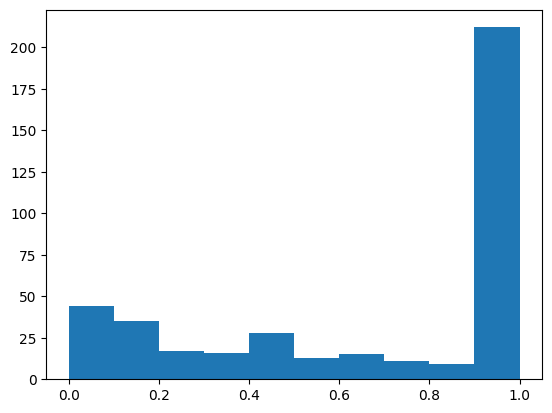

In [23]:
plt.hist(net_sham.ctx_ctx.sum(axis=0))

In [37]:
net_sham.ctx_ctx.sum(axis=0)[100:]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [13]:
net_sham.homeostasis("ctx", "ctx")

In [20]:
net_sham.ctx_ctx[ind_ctx][:, ind_ctx][0]

tensor([0.0970, 0.0970, 0.0970, 0.0970, 0.0970, 0.0970, 0.0970, 0.0969, 0.0970,
        0.0969, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0003, 0.0000, 0.0003, 0.0000, 0.0000, 0.0000,
        0.0003, 0.0003, 0.0003, 0.0003, 0.0000, 0.0003, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004,
        0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0024, 0.0024, 0.0024, 0.0024,
        0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0024, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0333, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

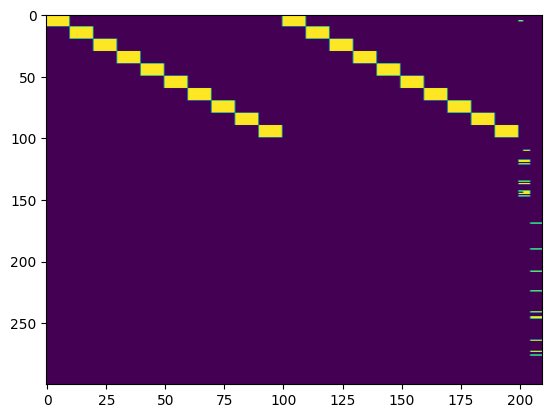

In [30]:
ctx_sleep_A = torch.stack(net_sham.activity_recordings["ctx"], axis=0)[net_sham.sleep_indices_A].T

lead_idx = ind_ctx[:100].long()
lead_set = set(lead_idx.tolist())

remaining_idx = torch.tensor(
    [i for i in range(ctx_sleep_A.shape[0]) if i not in lead_set],
    dtype=torch.long,
    device=ctx_sleep_A.device,
)

plot_idx = torch.cat([lead_idx, remaining_idx], dim=0)

ctx_sleep_A_ordered = ctx_sleep_A[plot_idx]

plt.imshow(ctx_sleep_A_ordered.cpu(), aspect='auto')


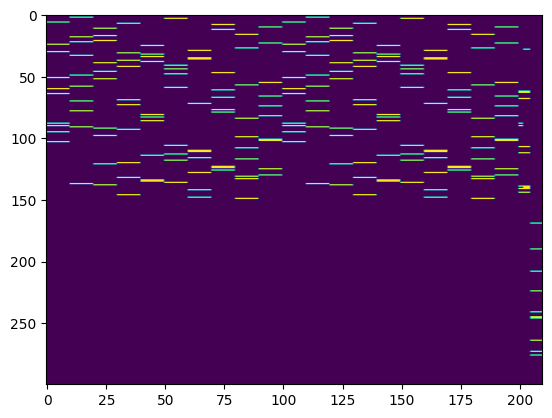

In [31]:
ctx_sleep_A = torch.stack(net_sham.activity_recordings["ctx"], axis=0)[net_sham.sleep_indices_A].T

plt.imshow(ctx_sleep_A.cpu(), aspect='auto')


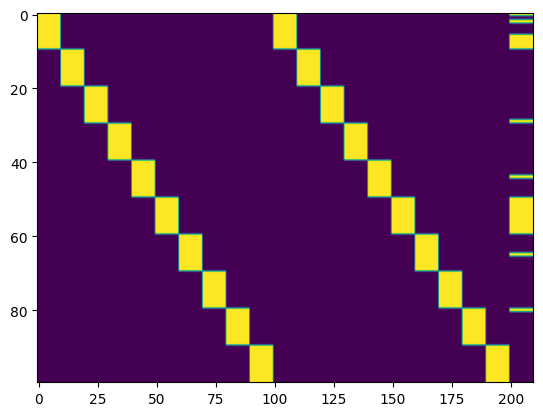

In [143]:
ctx_sleep_A = torch.stack(net_sham.activity_recordings["mtl_sensory"], axis=0)[net_sham.sleep_indices_A].T

plt.imshow(ctx_sleep_A.cpu(), aspect='auto')


In [144]:
ctx_sleep_A.shape

torch.Size([100, 210])

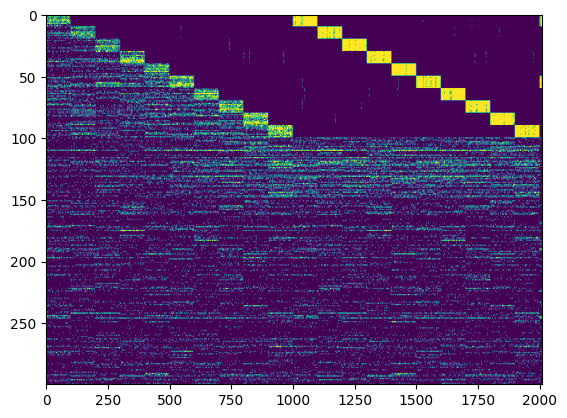

In [23]:
ctx_sleep_A = torch.stack(net_sham.activity_recordings["ctx"], axis=0)[net_sham.awake_indices].T

lead_idx = ind_ctx[:100].long()
lead_set = set(lead_idx.tolist())

remaining_idx = torch.tensor(
    [i for i in range(ctx_sleep_A.shape[0]) if i not in lead_set],
    dtype=torch.long,
    device=ctx_sleep_A.device,
)

plot_idx = torch.cat([lead_idx, remaining_idx], dim=0)

ctx_sleep_A_ordered = ctx_sleep_A[plot_idx]

plt.imshow(ctx_sleep_A_ordered.cpu(), aspect='auto')
